Cell ID 1 found at index 0


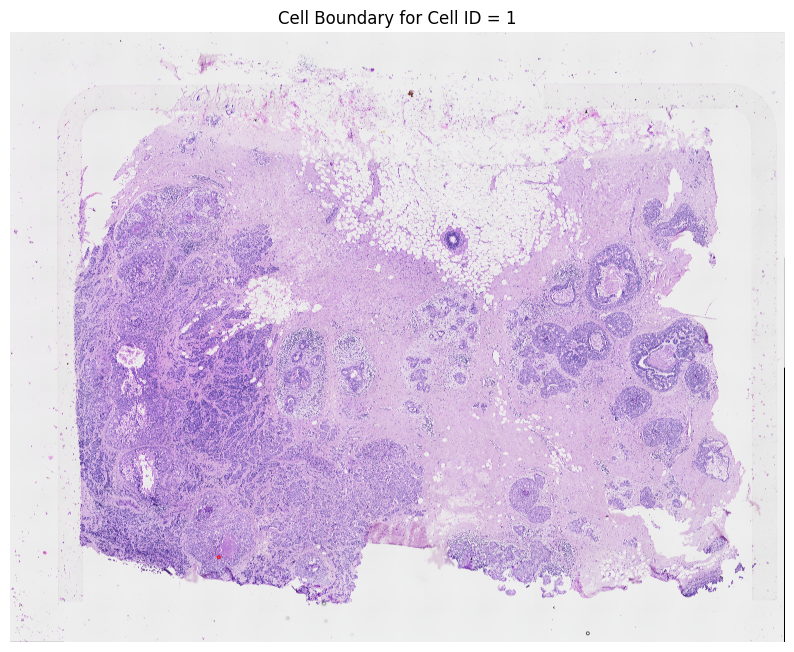

Saved: cell_1_boundary.png


In [4]:
import os
import zarr
import json
import tifffile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# --------------------------------------------------
# Paths
# --------------------------------------------------
BASE = "/home/puneet/mk/data/10X_HumandBreastCancer_data"

HE_IMAGE = os.path.join(BASE, "Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif")
CELLS_ZARR = os.path.join(BASE, "Xenium_output/outs/cells.zarr.zip")
ALIGN_CSV = os.path.join(BASE, "Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv")
EXPERIMENT_JSON = os.path.join(BASE, "Xenium_output/outs/experiment.xenium")

TARGET_CELL_ID = 1
POLY_SET_IDX = 1   # 0 = nucleus, 1 = cell boundary

# --------------------------------------------------
# Load Xenium data
# --------------------------------------------------
z = zarr.open(CELLS_ZARR, mode="r")

cell_ids = z["cell_id"][:]
polygon_vertices = z["polygon_vertices"]
polygon_num_vertices = z["polygon_num_vertices"]

# Find index of cell_id = 1
idx = np.where(cell_ids == TARGET_CELL_ID)[0][0]
print(f"Cell ID {TARGET_CELL_ID} found at index {idx}")

# --------------------------------------------------
# Load metadata
# --------------------------------------------------
with open(EXPERIMENT_JSON) as f:
    meta = json.load(f)

pixel_size_um = meta["pixel_size"]       # µm / pixel
um_to_px = 1.0 / pixel_size_um            # px / µm

# --------------------------------------------------
# Load alignment transform
# --------------------------------------------------
T_he = pd.read_csv(ALIGN_CSV, header=None).values
T_inv = np.linalg.inv(T_he)   # Xenium → H&E

# --------------------------------------------------
# Load H&E image
# --------------------------------------------------
img = tifffile.imread(HE_IMAGE)
if img.ndim == 3 and img.shape[0] in (3, 4):
    img = np.transpose(img[:3], (1, 2, 0))
elif img.ndim == 3 and img.shape[2] in (3, 4):
    img = img[:, :, :3]

# --------------------------------------------------
# Extract cell boundary (µm → H&E px)
# --------------------------------------------------
n_vert = polygon_num_vertices[POLY_SET_IDX, idx]
poly_um = polygon_vertices[POLY_SET_IDX, idx, :2 * n_vert].reshape(-1, 2)

poly_px = T_inv @ np.vstack([
    poly_um[:, 0] * um_to_px,
    poly_um[:, 1] * um_to_px,
    np.ones(n_vert)
])

poly_px = poly_px[:2].T

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(10, 8))
plt.imshow(img)

polygon = Polygon(
    poly_px,
    closed=True,
    fill=False,
    edgecolor="red",
    linewidth=2
)

plt.gca().add_patch(polygon)
plt.title("Cell Boundary for Cell ID = 1")
plt.axis("off")

# Save
out_path = "cell_1_boundary.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")

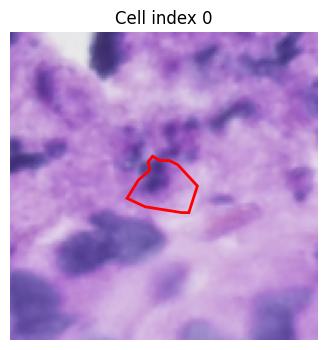

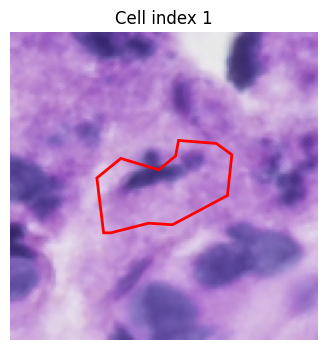

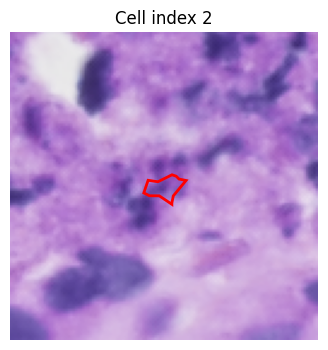

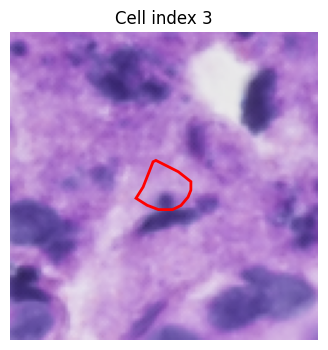

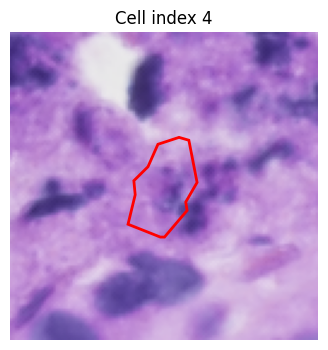

In [46]:
import zarr
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pandas as pd

# --------------------------------------------------
# Paths
# --------------------------------------------------
ZARR_PATH = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Xenium_output/outs/cells.zarr.zip"
H5_PATCH_PATH = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_patches.h5"
ALIGN_CSV = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv"

PATCH_SIZE = 128
POLY_SET_IDX = 1  # 0 = nucleus, 1 = cell

# --------------------------------------------------
# Load Zarr (polygons in µm)
# --------------------------------------------------
z = zarr.open(ZARR_PATH, mode="r")

cell_summary = np.array(z["cell_summary"])
polygon_vertices = z["polygon_vertices"]
polygon_num_vertices = z["polygon_num_vertices"]

cx_um = cell_summary[:, 0]
cy_um = cell_summary[:, 1]

# --------------------------------------------------
# Load transform (µm → H&E pixels)
# --------------------------------------------------
T_he = pd.read_csv(ALIGN_CSV, header=None).values
T_inv = np.linalg.inv(T_he)

mask_homog = np.array(z["masks/homogeneous_transform"])
S = mask_homog[0, 0]  # px / µm

T_full = T_inv @ np.array([
    [S, 0, 0],
    [0, S, 0],
    [0, 0, 1]
])

# --------------------------------------------------
# Load patches + patch centers
# --------------------------------------------------
with h5py.File(H5_PATCH_PATH, "r") as f:
    patches = f["patches"][:]
    x_px = f["pixel_x"][:]
    y_px = f["pixel_y"][:]

# --------------------------------------------------
# Function: show patch + boundary
# --------------------------------------------------
def show_patch_with_boundary(idx):
    patch = patches[idx]

    n_vert = polygon_num_vertices[POLY_SET_IDX, idx]
    if n_vert < 3:
        return

    # polygon in µm
    poly_um = polygon_vertices[POLY_SET_IDX, idx, :2 * n_vert].reshape(-1, 2)

    # µm → pixel (H&E)
    poly_h = np.c_[poly_um, np.ones(len(poly_um))].T
    poly_px = (T_full @ poly_h)[:2].T

    # pixel → patch-local
    x_local = poly_px[:, 0] - x_px[idx] + PATCH_SIZE / 2
    y_local = poly_px[:, 1] - y_px[idx] + PATCH_SIZE / 2

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(patch)

    ax.add_patch(
        Polygon(
            np.c_[x_local, y_local],
            closed=True,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
    )

    ax.set_title(f"Cell index {idx}")
    ax.axis("off")
    plt.show()

# --------------------------------------------------
# Display FIRST 5 cells
# --------------------------------------------------
for i in range(5):
    show_patch_with_boundary(i)


In [49]:
import zarr
import h5py
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm

# --------------------------------------------------
# Paths
# --------------------------------------------------
ZARR_PATH = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Xenium_output/outs/cells.zarr.zip"
H5_PATCH_PATH = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_patches.h5"
ALIGN_CSV = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv"

PATCH_SIZE = 128
POLY_SET_IDX = 1   # 1 = cell boundary

# --------------------------------------------------
# Load Zarr
# --------------------------------------------------
z = zarr.open(ZARR_PATH, mode="r")

polygon_vertices = z["polygon_vertices"]       # (2, N, 26)
polygon_num_vertices = z["polygon_num_vertices"]

# --------------------------------------------------
# Load transform (µm → pixel)
# --------------------------------------------------
T_he = pd.read_csv(ALIGN_CSV, header=None).values
T_inv = np.linalg.inv(T_he)

mask_homog = np.array(z["masks/homogeneous_transform"])
S = mask_homog[0, 0]  # px / µm

T_full = T_inv @ np.array([
    [S, 0, 0],
    [0, S, 0],
    [0, 0, 1]
])

# --------------------------------------------------
# Load H5 patches + centers
# --------------------------------------------------
with h5py.File(H5_PATCH_PATH, "r") as f:
    patches = f["patches"][:]
    x_px = f["pixel_x"][:]
    y_px = f["pixel_y"][:]

N = len(patches)

# --------------------------------------------------
# Allocate mask array
# --------------------------------------------------
masks = np.zeros((N, PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)

# --------------------------------------------------
# Generate masks
# --------------------------------------------------
for idx in tqdm(range(N), desc="Generating masks"):

    nv = polygon_num_vertices[POLY_SET_IDX, idx]
    if nv < 3:
        continue

    # polygon in µm
    poly_um = polygon_vertices[POLY_SET_IDX, idx, :2 * nv].reshape(-1, 2)

    # µm → global pixel
    poly_h = np.c_[poly_um, np.ones(nv)].T
    poly_px = (T_full @ poly_h)[:2].T

    # global pixel → patch-local
    x_local = poly_px[:, 0] - x_px[idx] + PATCH_SIZE / 2
    y_local = poly_px[:, 1] - y_px[idx] + PATCH_SIZE / 2

    pts = np.stack([x_local, y_local], axis=1).astype(np.int32)

    # draw filled polygon
    cv2.fillPoly(
        masks[idx],
        [pts],
        color=1
    )

# --------------------------------------------------
# Save masks into H5
# --------------------------------------------------
with h5py.File(H5_PATCH_PATH, "a") as f:
    if "masks" in f:
        del f["masks"]

    f.create_dataset(
        "masks",
        data=masks,
        compression="gzip"
    )

print("✅ Segmentation masks generated and saved to H5")


Generating masks: 100%|██████████| 167780/167780 [04:28<00:00, 625.62it/s]


✅ Segmentation masks generated and saved to H5


In [50]:
import h5py

h5_path = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_patches.h5"

with h5py.File(h5_path, "r") as f:
    print(" Keys in H5 file:\n")
    for key in f.keys():
        dset = f[key]
        print(f"{key:15s} → shape: {dset.shape}, dtype: {dset.dtype}")

 Keys in H5 file:

cell_ids        → shape: (167780,), dtype: uint32
centroid_um     → shape: (167780, 2), dtype: float32
coords_px       → shape: (167780, 2), dtype: float64
masks           → shape: (167780, 128, 128), dtype: uint8
patches         → shape: (167780, 128, 128, 3), dtype: uint8
pixel_x         → shape: (167780,), dtype: float64
pixel_y         → shape: (167780,), dtype: float64
polygon_num_vertices → shape: (167780,), dtype: int32
polygon_vertices_um → shape: (167780, 13, 2), dtype: float32


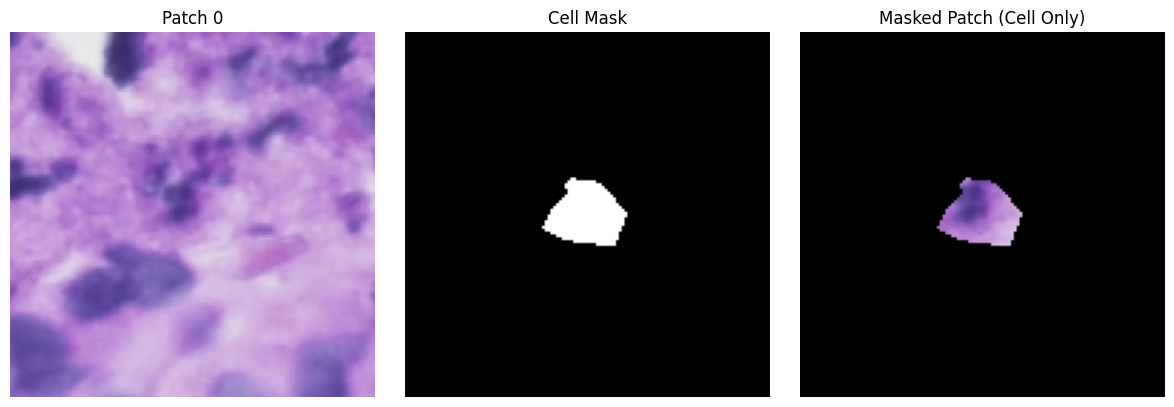

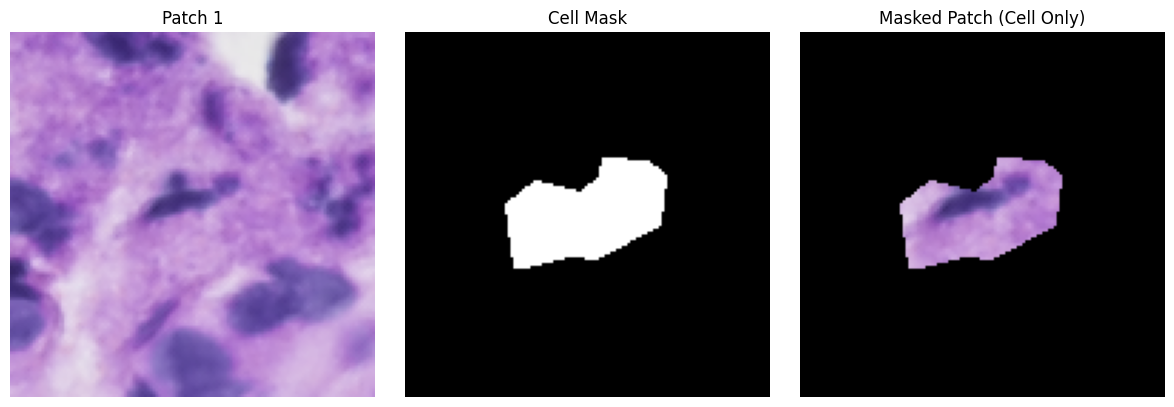

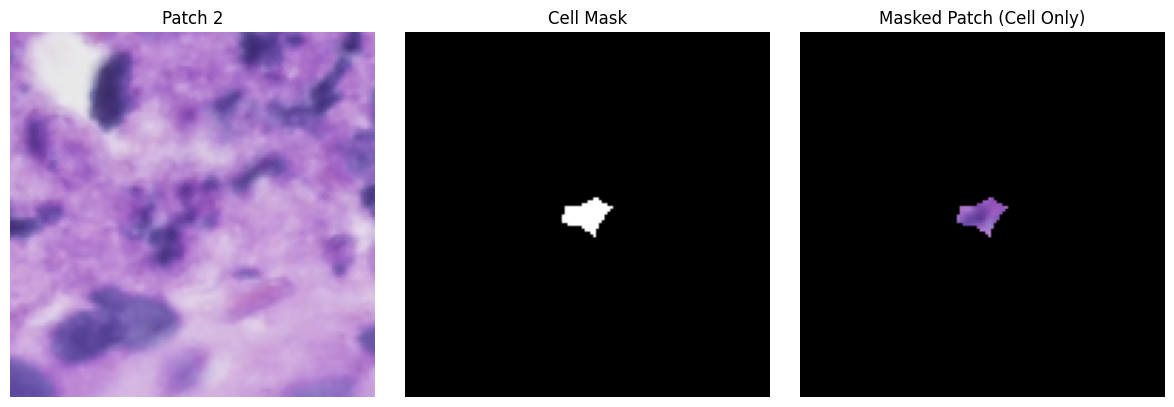

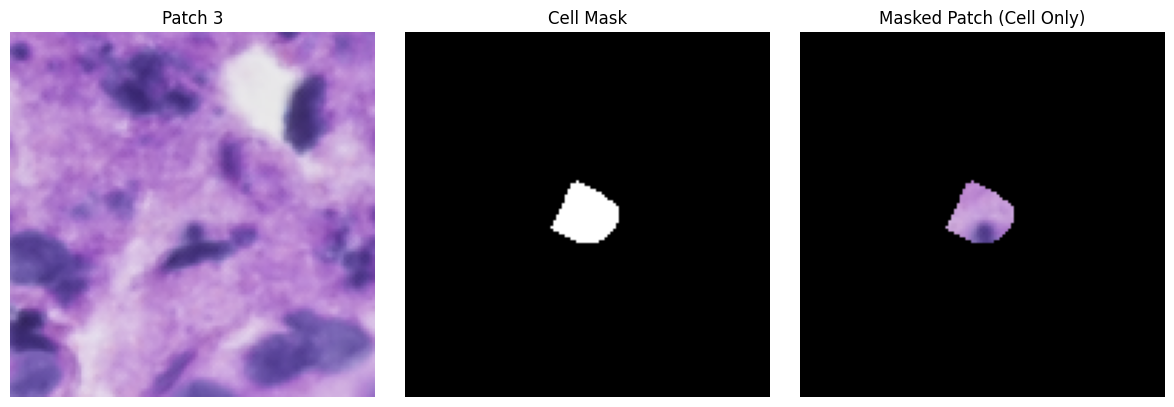

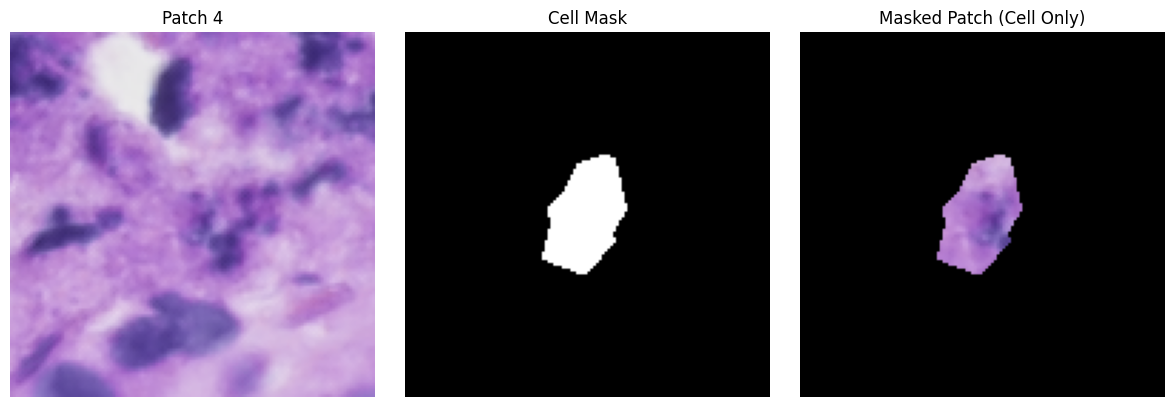

In [60]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Path
# --------------------------------------------------
H5_PATCH_PATH = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_patches.h5"

# --------------------------------------------------
# Load data
# --------------------------------------------------
with h5py.File(H5_PATCH_PATH, "r") as f:
    patches = f["patches"][:]    # (N, 128, 128, 3)
    masks   = f["masks"][:]      # (N, 128, 128)

# --------------------------------------------------
# Visualization
# --------------------------------------------------
for i in range(5):

    patch = patches[i]
    mask  = masks[i]

    # ✅ Apply mask (cell-only image)
    masked_patch = patch.copy()
    masked_patch[mask == 0] = 0

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 1️⃣ Original patch
    axes[0].imshow(patch)
    axes[0].set_title(f"Patch {i}")
    axes[0].axis("off")

    # 2️⃣ Binary mask
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Cell Mask")
    axes[1].axis("off")

    # 3️⃣ Masked patch (CELL ONLY)
    axes[2].imshow(masked_patch)
    axes[2].set_title("Masked Patch (Cell Only)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
import scanpy as sc

h5ad_path = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression.h5ad"

adata = sc.read_h5ad(h5ad_path)

print(" AnnData summary")
print(adata)

print("\n obs (cell metadata) columns:")
print(adata.obs.columns.tolist())

print("\n var (gene metadata) columns:")
print(adata.var.columns.tolist())

print("\n obsm keys:")
print(adata.obsm.keys())

print("\n uns keys:")
print(adata.uns.keys())

 AnnData summary
AnnData object with n_obs × n_vars = 167780 × 541
    obs: 'x_pixel', 'y_pixel', 'x_um', 'y_um', 'cell_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial_metadata'
    obsm: 'spatial'

 obs (cell metadata) columns:
['x_pixel', 'y_pixel', 'x_um', 'y_um', 'cell_id']

 var (gene metadata) columns:
['gene_ids', 'feature_types', 'genome']

 obsm keys:
KeysView(AxisArrays with keys: spatial)

 uns keys:
dict_keys(['spatial_metadata'])


In [13]:
import zarr
import scanpy as sc
import numpy as np

adata = sc.read_h5ad("/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression.h5ad")

cells_z = zarr.open("/home/puneet/mk/data/10X_HumandBreastCancer_data/Xenium_output/outs/cells.zarr.zip", mode="r")

# Load barcodes from cell_feature_matrix.h5
with h5py.File("/home/puneet/mk/data/10X_HumandBreastCancer_data/Xenium_output/outs/cell_feature_matrix.h5") as f:
    barcodes = [b.decode() for b in f["matrix/barcodes"][:]]

adata.obs["barcode"] = barcodes
adata.obsm["spatial_um"] = adata.obs[["x_um", "y_um"]].values

# Store transform (metadata only)
adata.uns["homogeneous_transform"] = cells_z["homogeneous_transform"][:]
adata.uns["coordinate_system"] = "xenium_um"

adata.write("/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression_fixed.h5ad")

In [59]:
import scanpy as sc

h5ad_path = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression_with_celltypes.h5ad"

adata = sc.read_h5ad(h5ad_path)

print(" AnnData summary")
print(adata)

print("\n obs (cell metadata) columns:")
print(adata.obs.columns.tolist())

print("\n var (gene metadata) columns:")
print(adata.var.columns.tolist())

print("\n obsm keys:")
print(adata.obsm.keys())

print("\n uns keys:")
print(adata.uns.keys())

 AnnData summary
AnnData object with n_obs × n_vars = 167780 × 541
    obs: 'x_pixel', 'y_pixel', 'x_um', 'y_um', 'cell_id', 'barcode', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'coordinate_system', 'homogeneous_transform', 'spatial_metadata'
    obsm: 'spatial', 'spatial_um'

 obs (cell metadata) columns:
['x_pixel', 'y_pixel', 'x_um', 'y_um', 'cell_id', 'barcode', 'cell_type']

 var (gene metadata) columns:
['gene_ids', 'feature_types', 'genome']

 obsm keys:
KeysView(AxisArrays with keys: spatial, spatial_um)

 uns keys:
dict_keys(['coordinate_system', 'homogeneous_transform', 'spatial_metadata'])


In [56]:
import scanpy as sc
import pandas as pd

# --------------------------------------------------
# Paths
# --------------------------------------------------
H5AD_PATH = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression_fixed.h5ad"
XLSX_PATH = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Cell_Barcode_Type_Matrices.xlsx"
SHEET_NAME = "Xenium R1 Fig1-5 (supervised)"

OUT_H5AD = "/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression_with_celltypes.h5ad"

# --------------------------------------------------
# Load AnnData
# --------------------------------------------------
adata = sc.read_h5ad(H5AD_PATH)
print("Loaded AnnData:", adata)

# --------------------------------------------------
# Load Excel (Barcode → Cluster)
# --------------------------------------------------
df = pd.read_excel(XLSX_PATH, sheet_name=SHEET_NAME)

# Keep only needed columns
df = df[["Barcode", "Cluster"]].dropna()

# Normalize barcode format
df["Barcode"] = df["Barcode"].astype(str).str.strip()

# --------------------------------------------------
# Create lookup dictionary
# --------------------------------------------------
barcode_to_cluster = dict(zip(df["Barcode"], df["Cluster"]))

print(f"Loaded {len(barcode_to_cluster)} barcode → cell_type mappings")

# --------------------------------------------------
# Match with AnnData
# --------------------------------------------------
adata.obs["barcode"] = adata.obs["barcode"].astype(str)

adata.obs["cell_type"] = adata.obs["barcode"].map(barcode_to_cluster)

# --------------------------------------------------
# Diagnostics
# --------------------------------------------------
matched = adata.obs["cell_type"].notna().sum()
total = adata.n_obs

print(f"Matched cell types: {matched} / {total}")
print("\nFirst 10 annotated cells:")
print(adata.obs[["barcode", "cell_type"]].head(10))

# --------------------------------------------------
# Save updated AnnData
# --------------------------------------------------
adata.write(OUT_H5AD)
print(f"\nSaved updated AnnData with cell types:\n{OUT_H5AD}")

Loaded AnnData: AnnData object with n_obs × n_vars = 167780 × 541
    obs: 'x_pixel', 'y_pixel', 'x_um', 'y_um', 'cell_id', 'barcode'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'coordinate_system', 'homogeneous_transform', 'spatial_metadata'
    obsm: 'spatial', 'spatial_um'
Loaded 167780 barcode → cell_type mappings
Matched cell types: 167780 / 167780

First 10 annotated cells:
   barcode       cell_type
1        1          DCIS_2
2        2          DCIS_2
3        3       Unlabeled
4        4  Invasive_Tumor
5        5          DCIS_2
6        6       Unlabeled
7        7       Unlabeled
8        8          DCIS_2
9        9   Macrophages_1
10      10   Macrophages_1

Saved updated AnnData with cell types:
/home/puneet/mk/data/10X_HumandBreastCancer_data/Processed_Output/cells_expression_with_celltypes.h5ad
